In [310]:
# Importing
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns

In [311]:
# current directory where script is located
base_path = os.getcwd()

# Joined the path to the dataset folder
train_path = os.path.join(base_path, 'dataset', 'adult.csv')

# Loading the data
train_df = pd.read_csv(train_path)
print("Data loaded successfully!")


Data loaded successfully!


In [ ]:
# Exploring data
print(train_df.shape)
train_df.head(5)

In [313]:
le = LabelEncoder() # Encoding for target
train_df["income"] = le.fit_transform(train_df["income"])

In [314]:
# Data Preprocessing and Feature Encoding.
train_df = train_df.drop(columns=["education", "fnlwgt", "relationship"])
train_df = train_df.replace("?", np.nan)
train_df = train_df.dropna()


X = train_df.drop(["income"], axis = 1)
y = train_df["income"]

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

ct = ColumnTransformer( transformers= [("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False),["workclass", "marital.status","occupation","race","native.country","sex"])],remainder="passthrough")
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

# get feature names
feature_names = ct.get_feature_names_out()
feature = [name.split("__")[1] for name in feature_names]
X_train = pd.DataFrame(X_train, columns= feature)
X_test = pd.DataFrame(X_test, columns=feature)



In [ ]:
# Model training 
model = RandomForestClassifier(n_estimators=150,max_depth=15, random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# How well the Algorithm
print(f"Train score :\n {model.score(X_train,y_train)}")
print(f"Train score :\n {model.score(X_test,y_test)}")
print("---"* 50)
print(f"Accuracy Score \n : {accuracy_score(y_test,y_pred)*100 :.3f}")
print("---"* 50)
print(f"confusion matrix : \n {confusion_matrix(y_test,y_pred)}")
print("---"* 50)
print(f"Classification Report :\n {classification_report(y_test, y_pred)}")

In [ ]:
# Model choosing feature 
importance = model.feature_importances_
feature_names = X_train.columns

ft_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)
print(ft_imp.head(10))

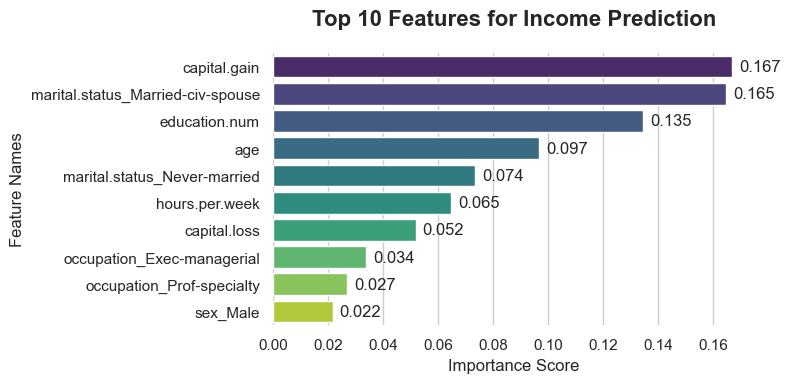

In [317]:
top_10_features = ft_imp.head(10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=top_10_features.values, 
    y=top_10_features.index, 
    palette="viridis",
    hue=top_10_features.index,
    legend=False
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=5)

# 5. Fine-tune labels and titles
plt.title("Top 10 Features for Income Prediction", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature Names", fontsize=12)

# 6. Clean up the layout
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Show the plot
plt.show()